# Постановка задачи
Вы стажируетесь в стартапе и вместе с командой работаете над улучшением сервиса по распознаванию лиц. Вашей компании поступил запрос на применение разработанного сервиса в рамках IT-конференции, спикерами на которой будут знаменитые люди.

Многие люди используют распознавание лиц просто как способ разблокировать телефон или отсортировать фотографии и даже не представляют всех возможностей этого мощного инструмента. Распознавание лиц активно используется маркетологами.
→ Coca-Cola использовала распознавание лиц по-разному во всём мире. Например, некоторые торговые автоматы Coca-Cola в Китае вознаграждали клиентов за переработку ёмкостей бренда, а на торговых автоматах в Австралии размещалась персонализированная реклама.

→ MAC Cosmetics используют технологию распознавания лиц в некоторых офлайн-магазинах, что позволяет покупателям виртуально «примерить» макияж с помощью имеющихся в магазине зеркал с дополненной реальностью.

Теперь давайте поможем и камерам их узнавать. Для этого обучим пятиклассовый классификатор, используя всю мощь предобученных сетей.

**Бизнес-задача:** разработать классификатор лиц, который автоматически определяет, кто из 5 известных спикеров изображён на фотографии, чтобы использовать его в сервисе распознавания лиц на IT-конференции.

**Техническая задача для специалиста:** обучить многоклассовую модель классификации изображений на 5 классов с использованием transfer learning и добиться accuracy > 0.85 на валидационной выборке, после чего визуализировать предсказания модели.

**Основные цели проекта:**
* Обучить классификатор для распознавания 5 человек.

* Использовать предобученную нейросеть и transfer learning.

* Достичь accuracy > 0.85 на валидационной выборке.

* Визуализировать результаты работы модели.

# Загрузка библиотек

In [4]:
!git clone --filter=blob:none --no-checkout https://github.com/Ar1sha/sf.git
%cd /content/sf
!git sparse-checkout set "Computer vision engineer"
!git checkout master
%cd "/content/sf/Computer vision engineer"

/content
Cloning into 'sf'...
remote: Enumerating objects: 269, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 269 (delta 21), reused 23 (delta 8), pack-reused 220 (from 1)
Receiving objects: 100% (269/269), 220.72 KiB | 907.00 KiB/s, done.
Resolving deltas: 100% (123/123), done.
/content/sf
remote: Enumerating objects: 3048, done.
remote: Counting objects: 100% (3048/3048), done.
remote: Compressing objects: 100% (3048/3048), done.
remote: Total 3048 (delta 0), reused 3045 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3048/3048), 10.88 MiB | 15.94 MiB/s, done.
Updating files: 100% (3918/3918), done.
Already on 'master'
Your branch is up to date with 'origin/master'.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

# Загрузка данных

In [9]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
train_dir = "./data/train"
valid_dir = "./data/valid"

train = datasets.ImageFolder(train_dir, transform=transform)
valid = datasets.ImageFolder(valid_dir, transform=transform)

# DataLoader для формирования батчей

In [10]:
train_loader = DataLoader(
    train,
    batch_size = 32,
    shuffle=True
)

valid_loader = DataLoader(
    valid,
    batch_size = 32,
    shuffle=False
)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Проверка Data Loader, батч

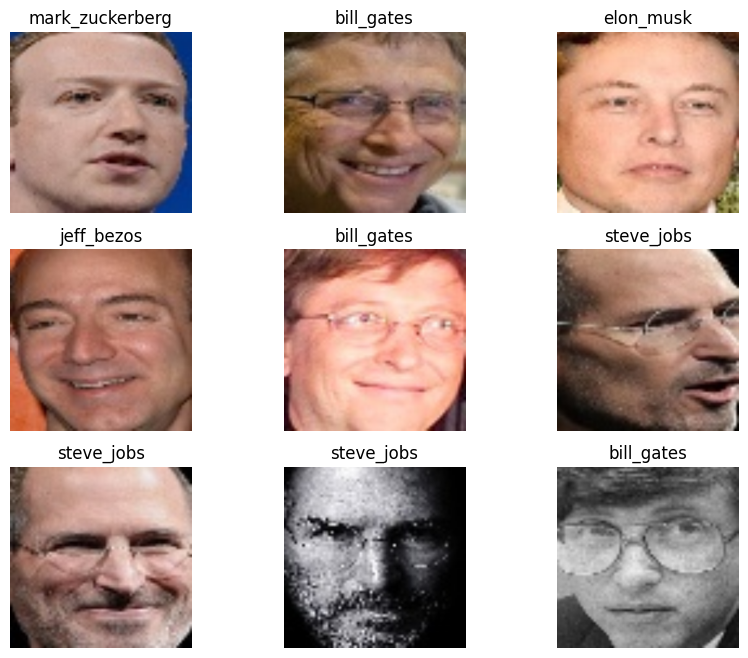

In [11]:
plt.figure(figsize=(10,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(train.classes[labels[i]])
    plt.axis("off")
plt.show()

# Предобученная модель

In [12]:
model = models.resnet18(weights='DEFAULT')
model.fc = torch.nn.Linear(model.fc.in_features, 5)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 110MB/s]


Linear(in_features=512, out_features=5, bias=True)


# Критерий и опимизация

In [13]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

почему

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss= criterion(outputs,labels)

    loss.backward()
    optimizer.step()

KeyboardInterrupt: 

In [ ]:
print(torch.cuda.is_available())

False
